In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import json
import argparse
import copy
from tqdm import tqdm
import torch

import warnings

def short_formatwarning(msg, category, filename, lineno, line=None):
    return f"{os.path.basename(filename)}:{lineno}: {category.__name__}: {msg}\n"

warnings.formatwarning = short_formatwarning
warnings.filterwarnings("always", category=RuntimeWarning)

from cosmoglint.datasets import MeshDataset, MeshCtxDataset
from cosmoglint.utils import normalize, namespace_to_dict
from cosmoglint.model.transformer import transformer_model

from matplotlib.colors import LogNorm

gpu_id = 1
device = torch.device("cuda:{:d}".format(gpu_id) if torch.cuda.is_available() else "cpu")

def plot_binned_mean(x, value, window_size, show_diff=False, ymin=None, **kwargs):
    x = np.asarray(x)
    value = np.asarray(value)

    n = len(value)
    n_bin = n // window_size

    if n_bin == 0:
        print("Warning: No data to plot.")
        return None, None

    # 端数は捨てる
    x_trim = x[:n_bin * window_size]
    v_trim = value[:n_bin * window_size]

    # window_size 個ずつまとめる
    x_bin = x_trim.reshape(n_bin, window_size).mean(axis=1)
    y_bin = v_trim.reshape(n_bin, window_size).mean(axis=1)

    if show_diff:
        ymin = y_bin.min() - 1e-3 if ymin is None else ymin
        y_plot = y_bin - ymin
        print("ymin plot:", ymin)
    else:
        y_plot = y_bin

    plt.plot(x_bin, y_plot, **kwargs)

    return x_bin, y_plot

def calc_length(x, threshold, ref_param=0, skip_length=0): 
    # skip the first element (central)
    # generated: (num_samples, seq_length, num_features_in)
    num_samples, seq_length, num_features_in = x.shape
    length = np.zeros(num_samples, dtype=int)
    for i in range(num_samples):
        count = skip_length
        for j in range(skip_length, seq_length):
            count = j
            if x[i,j,ref_param] < threshold:
                break
        length[i] = count
    return length

def calc_ngal_th(x, threshold, ref_param=0): 
    # skip the first element (central)
    # generated: (num_samples, seq_length, num_features_in)
    num_samples, seq_length, num_features_in = x.shape
    ngal = np.zeros(num_samples, dtype=int)
    for i in range(num_samples):
        if x[i,0,ref_param] > threshold:
            ngal[i] += 1
        for count, j in enumerate(range(1, seq_length)):
            if x[i,j,ref_param] < threshold:
                break
        ngal[i] += count

    return ngal

def my_savefig(fout, tight_layout=True):
    if tight_layout:
        plt.tight_layout()
    plt.savefig(fout, bbox_inches="tight")
    print(f"Saved figure to {fout}")

base_dir = "../scripts/runs/output_transformer_mesh"

# Load Model and Plot Loss

opt:  Namespace(gpu_id='0', output_dir='./runs/output_transformer_mesh/transformer_33_ep500_bs256_w1', seed=12345, show_pbar=True, config_file='./configs/config_mesh_33.yaml', train_ratio=0.9, batch_size=256, num_epochs=500, lr=0.0001, dropout=0.0, sampler_weight_min=1.0, save_freq=50, exclude_ratio=0.5, sampler_xmin=0.1, sampler_xmax=0.3, data_path=['../data/mesh/TNG300-1/TNG300-1_33.h5'], data_path_mesh=['../data/mesh/TNG300-3-Dark/TNG300-3-Dark_dm_33_keep0.10_npix256.h5'], global_param_file=None, indices=None, norm_param_file='../data/mesh/param_files/norm_params_33_npix256.json', dataset='mesh_ctx', npix_patch=16, npix_exclude=128, ndata=100000, input_features=['density_map'], output_features=['SubhaloSFR', 'SubhaloStellarMass', 'SubhaloPos:0', 'SubhaloPos:1', 'SubhaloPos:2'], global_features=None, max_length=100, model_name='mesh_sequence_conditioned_transformer', d_model=128, num_layers=4, num_heads=8, num_features_out=64, use_flat_representation=True, num_features_cond=1, num_fe

transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True


ymin plot:  2.219395868622262
ymin plot:  2.266263623218268
Final mean validation loss: 2.258


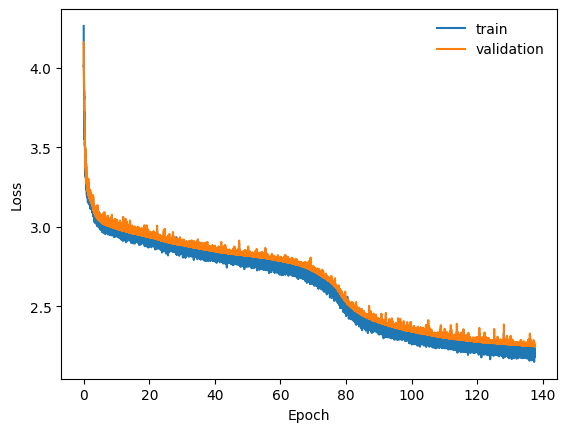

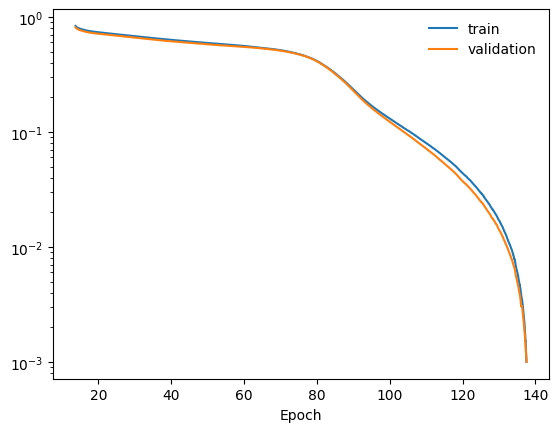

In [ ]:
snapshot_number = 33
model_dir = "{}/transformer_{:d}_ep500_bs256_w1".format(base_dir, snapshot_number)

if os.path.exists(model_dir):
    output_dir = "{}/figures".format(model_dir)
    os.makedirs(output_dir, exist_ok=True)
else:
    raise ValueError(f"Directory does not exist: {model_dir}")

### load parameters
with open("{}/args.json".format(model_dir), "r") as f:
    opt = json.load(f, object_hook=lambda d: argparse.Namespace(**d))
    opt.norm_param_dict = namespace_to_dict(opt.norm_param_dict)
print("opt: ", opt)

### load model
model = transformer_model(opt)
label = ""
model.load_state_dict(torch.load("{}/model{}.pth".format(model_dir, label), map_location=device))
model.to(device)

model.eval()
print(model)

### plot loss 
loss = np.loadtxt("{}/log.txt".format(model_dir), comments="#")
plt.figure()

x = loss[:,0]
plt.plot(x, loss[:,1], label="train")
#plot_running_mean(x, loss[:,2], 100, label="validation")
plt.plot(x, loss[:,2], label="validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(frameon=False)

plt.figure()
dx = min(int(len(x)/10), 10000)
plt.xlabel("Epoch")
plt.yscale("log")
ymin = None
#plt.ylabel(r"${\rm Loss} - %.2f$"%(ymin))

plot_binned_mean(x, loss[:,1], dx, show_diff=True, label="train", ymin=ymin)
plot_binned_mean(x, loss[:,2], dx, show_diff=True, label="validation", ymin=ymin)
#plt.grid()
plt.legend(frameon=False)

print("Final mean validation loss: {:.3f}".format(loss[-100:,2].mean()))

pos_idx = [opt.output_features.index("SubhaloPos:0"), opt.output_features.index("SubhaloPos:1"), opt.output_features.index("SubhaloPos:2")]
sfr_idx = opt.output_features.index( "SubhaloSFR" )
mstar_idx = opt.output_features.index( "SubhaloStellarMass" )

# Generate galaxies

In [3]:
from torch.utils.data import DataLoader

### True data ###
opt.data_path = "../data/mesh/TNG300-1/TNG300-1_{:d}.h5".format(snapshot_number)
opt.data_path_mesh = "../data/mesh/TNG300-3-Dark/TNG300-3-Dark_dm_33_keep0.10_npix256.h5"

opt.ndata = 10
round_id = 0
round_id = None
dataset_true = MeshCtxDataset(opt, exclude_ratio=opt.exclude_ratio, use_excluded_region=True, round_id=round_id)
#dataset_true = HaloDatasetCtx(opt, exclude_ratio=0, use_excluded_region=False)

loader = DataLoader(dataset_true, batch_size=opt.batch_size, shuffle=False)
batch = next(iter(loader))
x_true = batch["condition"]
x_true = {k: v.to(device) for k, v in x_true.items()}
y_true = batch["target"].to(device)
mask = batch["mask"].to(device)

### set threshold
threshold = normalize(1, opt.output_features[0], opt.norm_param_dict)
bin_of_threshold = int(threshold * opt.num_features_out)
print("threshold: ", threshold)
print("bin of threshold: ", bin_of_threshold)

prob_threshold = 1e-5 # p = 0 if p < prob_threshold

### model output ###
generated = []

batch_size = opt.batch_size
num_batch = (len(x_true) + batch_size - 1) // batch_size

count = 0
with torch.no_grad():
    y_pred, _ = model.generate(x_true, stop_criterion=threshold, prob_threshold=prob_threshold, monotonicity_start_index=0) #, max_ids=max_ids) 
    
x_npy = x_true["mesh3d"].detach().cpu().numpy() # (batch, num_condition) -> (batch,)
x_npy_phys = normalize(x_npy, "density_map", opt.norm_param_dict, inverse=True)
boundary = x_true["boundary"].detach().cpu().numpy()
lo = boundary[:,:3]
hi = boundary[:,3:]
y_ctx_npy = x_true["context"].detach().cpu().numpy()
y_tgt_npy = y_true.detach().cpu().numpy()
y_pred_npy = y_pred.detach().cpu().numpy()

if opt.use_flat_representation:
    y_ctx_npy = y_ctx_npy.reshape(len(y_ctx_npy), -1, opt.num_features_in)
    y_tgt_npy = y_tgt_npy.reshape(len(y_tgt_npy), -1, opt.num_features_in)
    y_pred_npy = y_pred_npy.reshape(len(y_pred_npy), -1, opt.num_features_in)

    mask = mask.reshape(len(mask), -1, opt.num_features_in)

# Input file (mesh): ../data/mesh/TNG300-3-Dark/TNG300-3-Dark_dm_33_keep0.10_npix256.h5
# Input file (galaxy): ../data/mesh/TNG300-1/TNG300-1_33.h5
# Use excluded region


Loading data: 100%|██████████| 10/10 [00:00<00:00, 693.95it/s]

threshold:  0.0
bin of threshold:  0


(10, 3) (10, 100, 5) (10, 3)
(10, 3) (10, 100, 5) (10, 3)
(10, 3) (10, 100, 5) (10, 3)
(10, 3) (10, 100, 5) (10, 3)
(10, 3) (10, 100, 5) (10, 3)
(10, 3) (10, 100, 5) (10, 3)
(10, 3) (10, 100, 5) (10, 3)
(10, 3) (10, 100, 5) (10, 3)
(10, 3) (10, 100, 5) (10, 3)
(10, 3) (10, 100, 5) (10, 3)


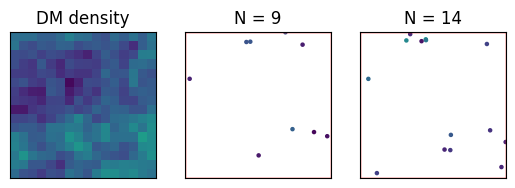

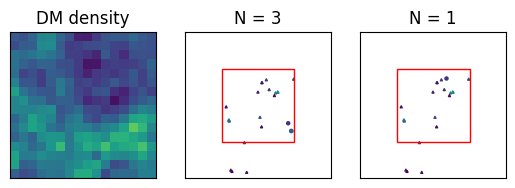

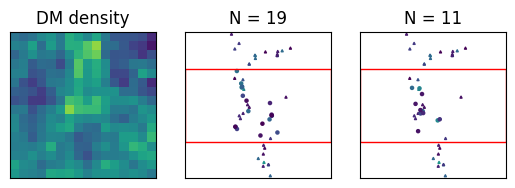

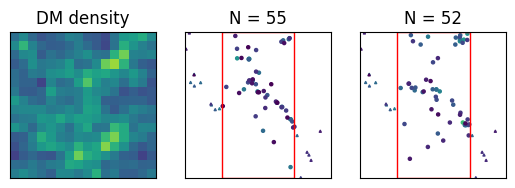

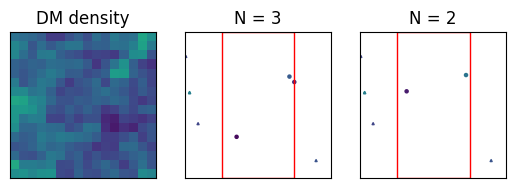

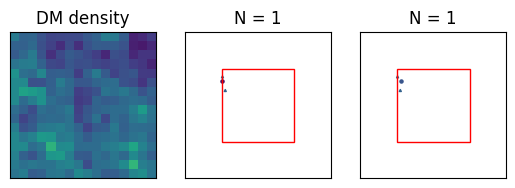

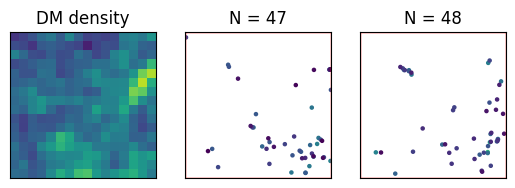

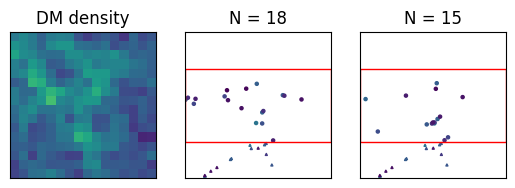

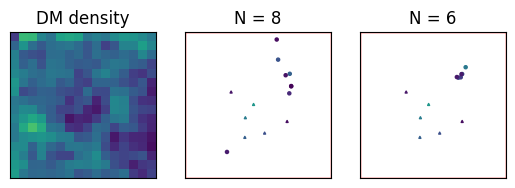

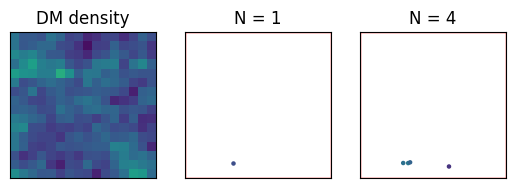

In [4]:
from matplotlib.patches import Rectangle
from plot_utils import plot_scatter

def my_plot_scatter(y, **kwargs):
    plot_scatter(y, x_idx=pos_idx[0], y_idx=pos_idx[1], color_idx=sfr_idx, mask_idx="all", **kwargs)

vmin=1
vmax=3.5

vmin=1.2
vmax=3.
#vmin=None
#vmax=None
for i in range(10): #[0, 1, 2, 3]:

    plt.figure()
    plt.subplot(1, 3, 1)
    image = np.log10( x_npy_phys[i].mean(axis=2) )
    #image = x_npy_phys[i].mean(axis=2)
    
    #image = x[i,:,:,0].detach().cpu().numpy()  # Use the log10 of the mean density
    # image with 0 at lower left corner

    plt.title("DM density")
    plt.imshow(image.T, extent=[0, 1, 0, 1], origin="lower", vmin=vmin, vmax=vmax)
    plt.xticks([])
    plt.yticks([])
    #plt.colorbar()

    ax = plt.subplot(1, 3, 2)
    print(lo.shape, y_ctx_npy.shape, hi.shape)
    mask = (lo[i,2] < y_ctx_npy[i,:,2]) & (y_ctx_npy[i,:,2] <= hi[i,2])
    my_plot_scatter(y_ctx_npy[i][mask], marker="^", s=2)
    mask = (lo[i,2] < y_tgt_npy[i,:,2]) & (y_tgt_npy[i,:,2] <= hi[i,2])
    my_plot_scatter(y_tgt_npy[i][mask])
    ax.add_patch(Rectangle((lo[i,0], lo[i,1]), (hi-lo)[i,0], (hi-lo)[i,1], facecolor="none", edgecolor="red"))
    
    ax = plt.subplot(1, 3, 3)
    mask = (lo[i,2] < y_ctx_npy[i,:,2]) & (y_ctx_npy[i,:,2] <= hi[i,2])
    my_plot_scatter(y_ctx_npy[i][mask], marker="^", s=2)
    mask = (lo[i,2] < y_pred_npy[i,:,2]) & (y_pred_npy[i,:,2] <= hi[i,2])
    my_plot_scatter(y_pred_npy[i][mask])
    ax.add_patch(Rectangle((lo[i,0], lo[i,1]), (hi-lo)[i,0], (hi-lo)[i,1], facecolor="none", edgecolor="red"))

    #print(y_pred_npy[i])

Saved figure to ../scripts/runs/output_transformer_mesh/transformer_33_ep500_bs256_w1/figures/example_results.pdf


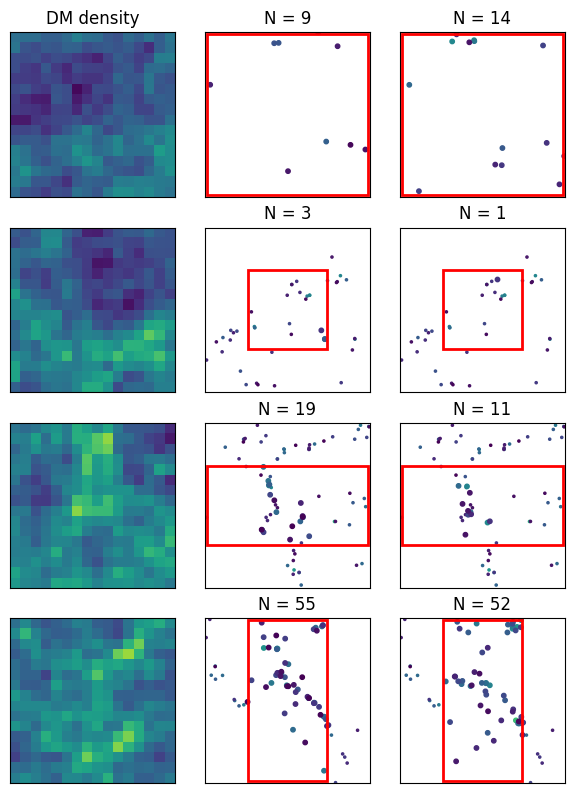

In [5]:
from matplotlib.patches import Rectangle
from plot_utils import plot_scatter
def my_plot_scatter(y, **kwargs):
    plot_scatter(y, x_idx=pos_idx[0], y_idx=pos_idx[1], color_idx=sfr_idx, **kwargs)

vmin=1
vmax=3.5

vmin=1.2
vmax=3.
#vmin = None
#vmax = None

nmap = 4
plt.figure(figsize=(3*2, nmap*2))
plt.subplots_adjust(hspace=0.1)
for count, i in enumerate([0,1,2,3]): #[6,12,4,8]): 
    plt.subplot(nmap, 3, 1+count*3)
    image = np.log10( x_npy_phys[i].mean(axis=2) )
    #image = x[i,:,:,0].detach().cpu().numpy()  # Use the log10 of the mean density
    # image with 0 at lower left corner

    if count == 0:
        plt.title("DM density")
    plt.imshow(image.T, extent=[0, 1, 0, 1], origin="lower", vmin=vmin, vmax=vmax)
    plt.xticks([])
    plt.yticks([])
    #plt.colorbar()

    ax = plt.subplot(nmap, 3, 2+count*3)
    dx = 0.01
    if count == 0:
        plt.title("TNG")

    my_plot_scatter(y_ctx_npy[i], marker=".", s=10)
    my_plot_scatter(y_tgt_npy[i], s=10, lo=lo[i], hi=hi[i])
    ax.add_patch(Rectangle((lo[i,0]+dx, lo[i,1]+dx), (hi-lo)[i,0]-2*dx, (hi-lo)[i,1]-2*dx, lw=2, facecolor="none", edgecolor="red"))
    
    ax = plt.subplot(nmap, 3, 3+count*3)
    if count == 0:
        plt.title("Generated")
    my_plot_scatter(y_ctx_npy[i], marker=".", s=10)
    my_plot_scatter(y_pred_npy[i], s=10, lo=lo[i], hi=hi[i])
    ax.add_patch(Rectangle((lo[i,0]+dx, lo[i,1]+dx), (hi-lo)[i,0]-2*dx, (hi-lo)[i,1]-2*dx, lw=2,facecolor="none", edgecolor="red"))

    #print(y_pred_npy[i])

my_savefig("{}/example_results.pdf".format(output_dir))

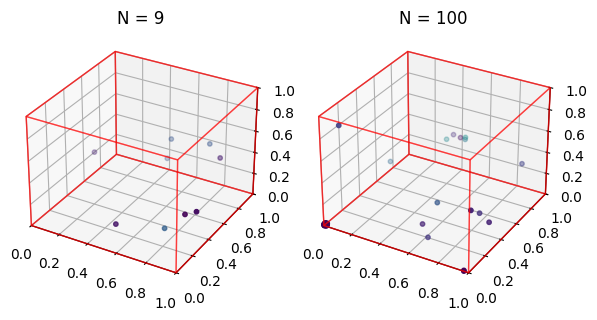

In [6]:
from plot_utils import plot_3d_scatter, draw_cube
def my_plot_3d_scatter(y, **kwargs):
    plot_3d_scatter(y, x_idx=pos_idx[0], y_idx=pos_idx[1], z_idx=pos_idx[2], color_idx=sfr_idx, **kwargs)

rotate = False

if rotate:
    %matplotlib widget
    syncing = False  

for i in range(20): #[0, 1, 2, 3]:
    fig = plt.figure(figsize=(6,3))
    
    ax1 = fig.add_subplot(121, projection='3d')
    #plot_3d_scatter(y_ctx_npy[i], ax, marker=".", s=10)
    my_plot_3d_scatter(y_tgt_npy[i], ax=ax1)
    draw_cube(ax1, lo[i], hi[i])
    
    ax2 = fig.add_subplot(122, projection='3d')
    #plot_3d_scatter(y_ctx_npy[i], ax, marker=".", s=10)
    my_plot_3d_scatter(y_pred_npy[i], ax=ax2)
    draw_cube(ax2, lo[i], hi[i])

    plt.tight_layout()

    if rotate:
        def sync_axes(src, dst):
            dst.view_init(elev=src.elev, azim=src.azim)
            fig.canvas.draw_idle()

        def on_move(event):
            global syncing
            if syncing:
                return
            if event.inaxes in (ax1, ax2):
                syncing = True
                if event.inaxes is ax1:
                    sync_axes(ax1, ax2)
                else:
                    sync_axes(ax2, ax1)
                syncing = False

        cid = fig.canvas.mpl_connect("motion_notify_event", on_move)

    plt.show()
    break

2026-02-12 18:27:42.751 (   0.500s) [    70CDC74F3480]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=localhost:11.0


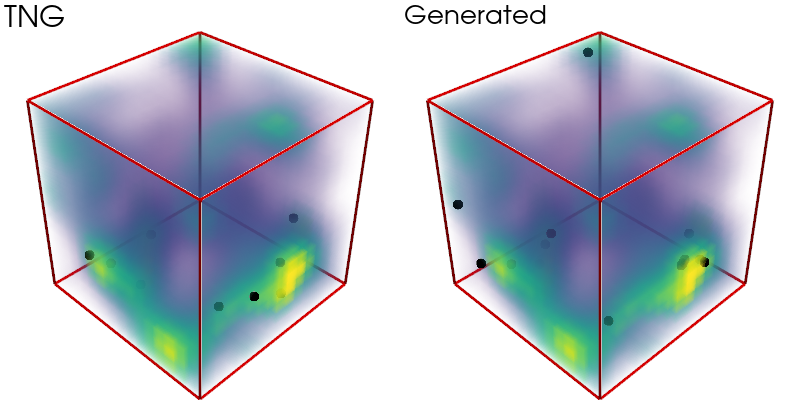

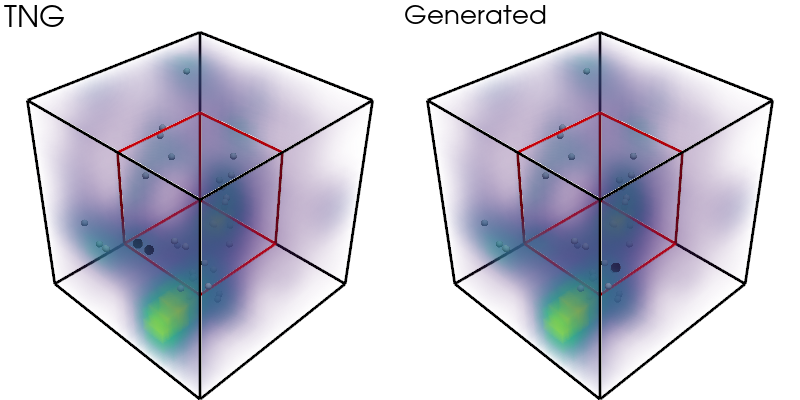

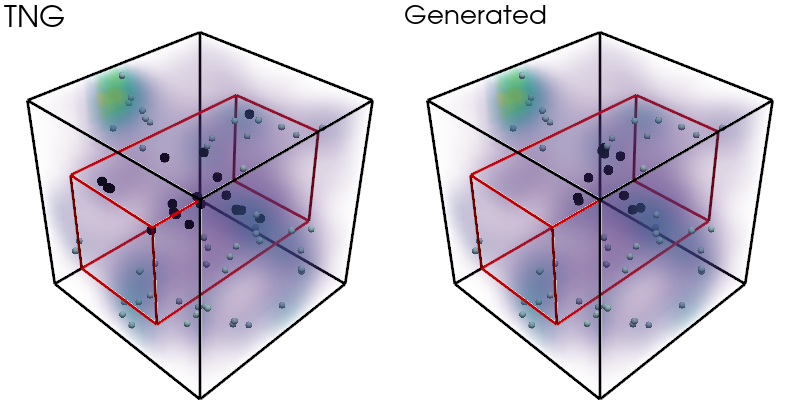

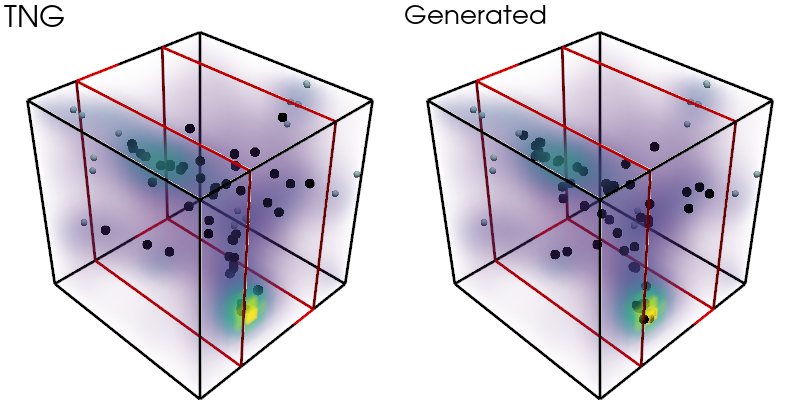

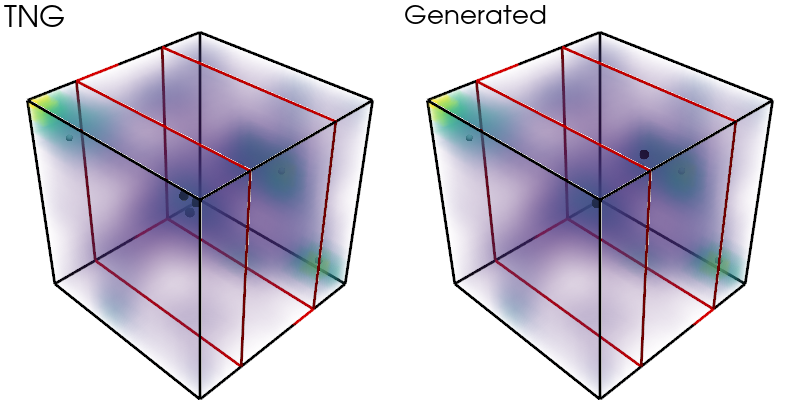

In [7]:
import pyvista as pv
pv.set_jupyter_backend('static') 

from scipy.ndimage import gaussian_filter
        
color_idx = 4
for i_batch in range(5):   
    #data, ynow_true, ynow_pred = x_npy[i], y_true_npy[i], y_pred_npy[i]
    #clim = [x_npy.min() * 3.0, x_npy.max() * 0.6]
    #opacity = "sigmoid_3"

    data, ynow_ctx, ynow_tgt, ynow_pred = x_npy_phys[i_batch], y_ctx_npy[i_batch], y_tgt_npy[i_batch], y_pred_npy[i_batch]
    opacity = "linear"
    clim = None
    cmap_points = None
    use_point = True

    data = gaussian_filter(data, sigma=1)

    mask_ctx = (ynow_ctx > 0).all(axis=-1)
    mask_tgt = (ynow_tgt > 0).all(axis=-1)
    mask_pred = (ynow_pred > 0).all(axis=-1)

    ### show data
    _, nx, ny, nz = data.shape
    grid = pv.ImageData()
    grid.origin = (0, 0, 0)
    grid.spacing = (1/nx, 1/ny, 1/nz)
    grid.dimensions = (nx+1, ny+1, nz+1)    

    grid.cell_data["values"] = data.flatten(order="F")

    point_list = [ynow_tgt[mask_tgt], ynow_pred[mask_pred]]
    title_list = ["TNG", "Generated"]
    nplot = len(point_list)
    plotter = pv.Plotter(shape=(1, nplot), border=False, window_size=(800, 400))

    for i, points in enumerate(point_list):
        plotter.subplot(0, i)
        plotter.add_text(title_list[i], font_size=12)
        plotter.add_volume(grid.copy(deep=True), cmap="viridis", show_scalar_bar=False, opacity=opacity, clim=clim)
        
        ### show points
        if points is not None:
            if len(points) > 0:
                point_cloud = pv.PolyData(points[:,pos_idx])
                if cmap_points is None:
                    plotter.add_mesh(point_cloud, color="black", point_size=10, render_points_as_spheres=True, show_scalar_bar=False)
                else:
                    point_cloud["scalars"] = points[:,color_idx]
                    plotter.add_mesh(point_cloud, scalars="scalars", cmap=cmap_points, point_size=10, render_points_as_spheres=True, show_scalar_bar=False)

        if mask_ctx.sum() > 0:
            plotter.add_mesh(ynow_ctx[mask_ctx][:,pos_idx], point_size=7, render_points_as_spheres=True)

        ### show outline
        bounds = [0, 1, 0, 1, 0, 1]
        box = pv.Box(bounds=bounds)
        plotter.add_mesh(box, color="black", style='wireframe', line_width=3)

        #plotter.show_axes()

        bounds = [
            lo[i_batch,0], hi[i_batch,0],
            lo[i_batch,1], hi[i_batch,1],
            lo[i_batch,2], hi[i_batch,2],
        ]
        box = pv.Box(bounds=bounds)

        plotter.add_mesh(box, color='red', style='wireframe', line_width=3)
    plotter.show(auto_close=False)

    ### save screenshot
    fsave="{}/volume_{:d}.png".format(output_dir, i_batch)
    plotter.screenshot(fsave, return_img=False)
    plotter.close()

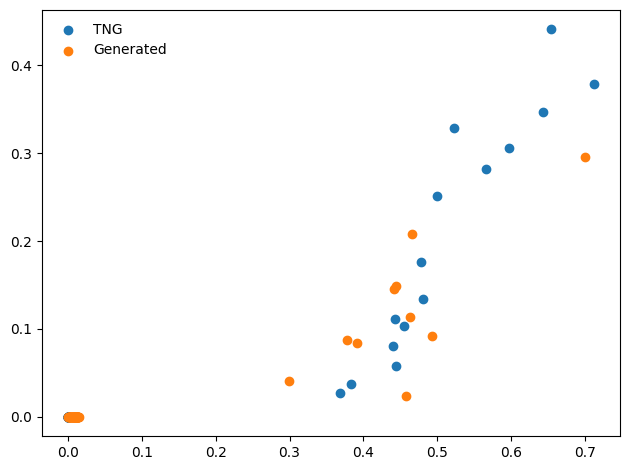

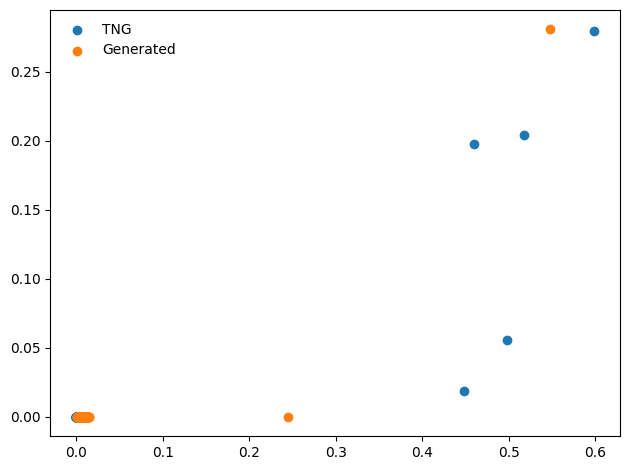

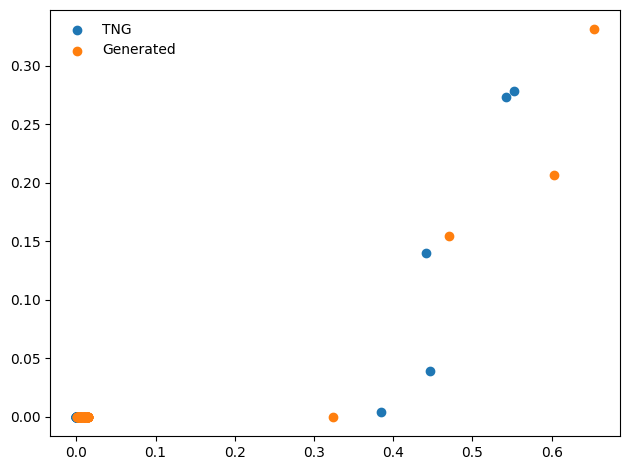

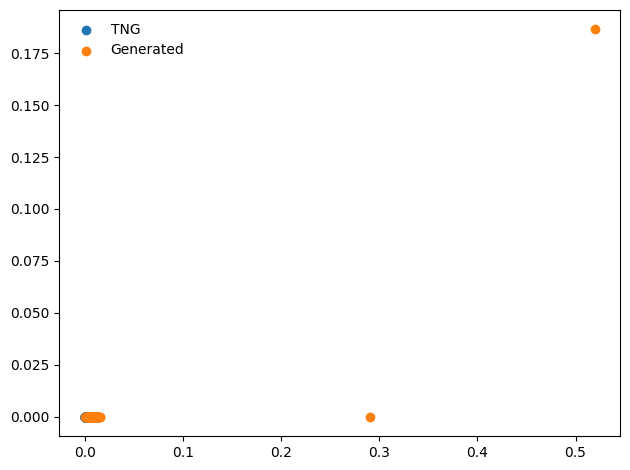

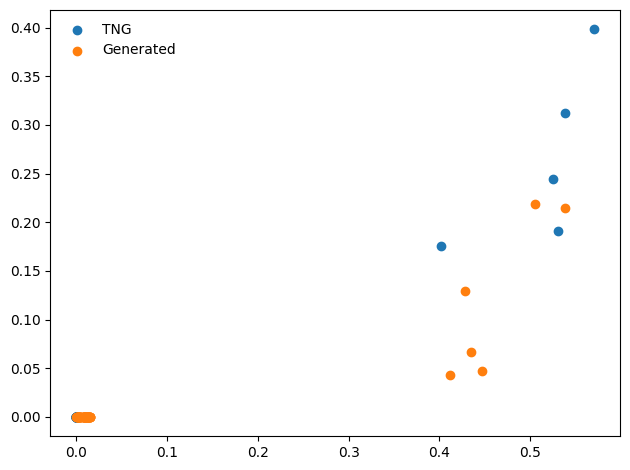

In [12]:
for i in range(5): 
    fig = plt.figure()

    plt.scatter(y_tgt_npy[i,:,mstar_idx], y_tgt_npy[i,:,sfr_idx], label="TNG")
    plt.scatter(y_pred_npy[i,:,mstar_idx], y_pred_npy[i,:,sfr_idx], label="Generated")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# Probability distribution

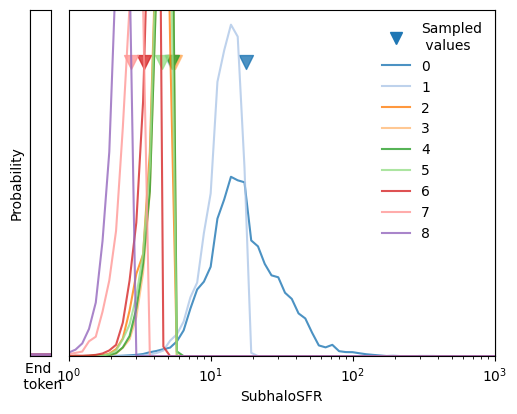

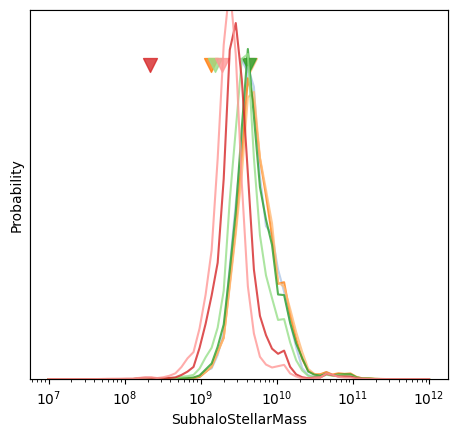

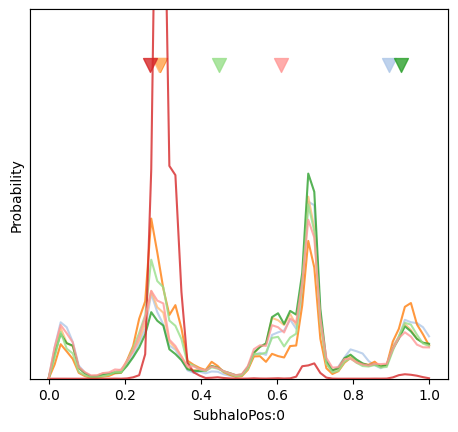

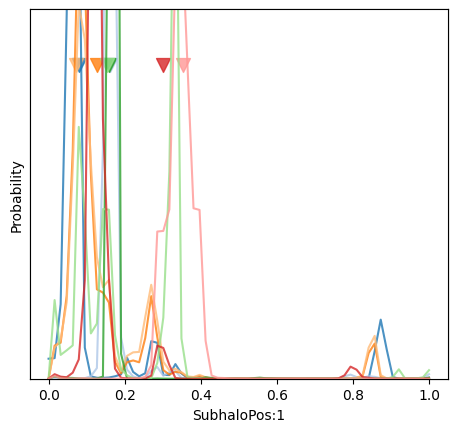

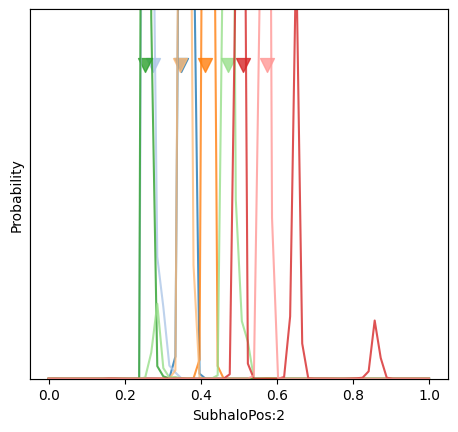

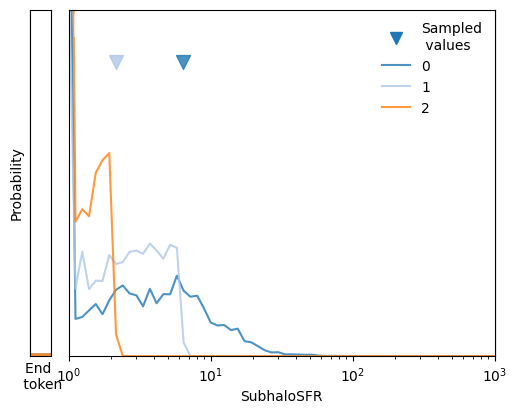

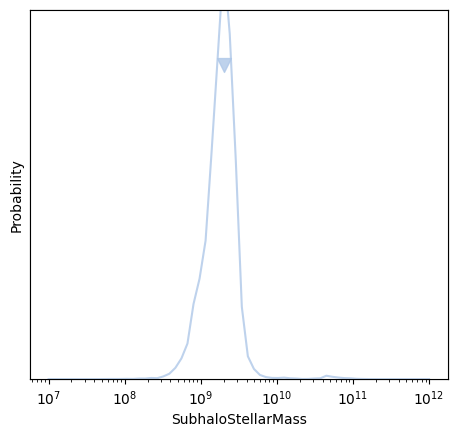

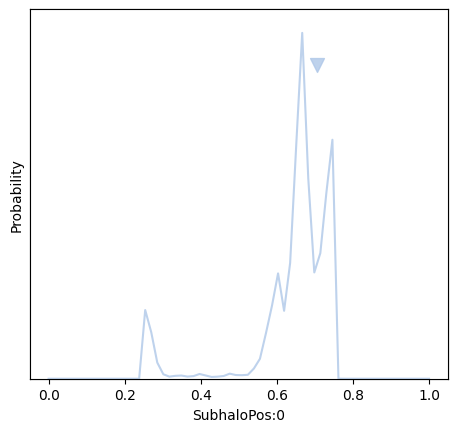

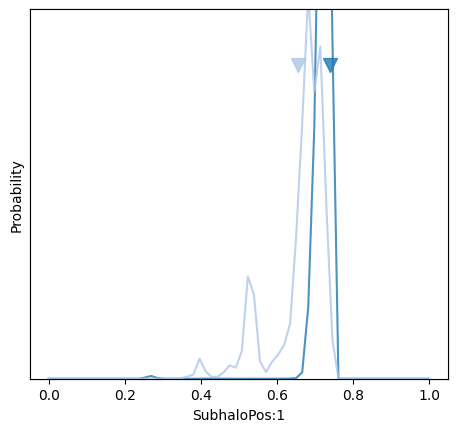

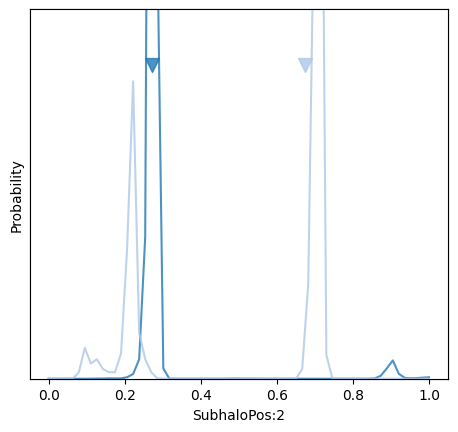

In [26]:
import matplotlib.gridspec as gridspec

cmap = plt.get_cmap("tab20")
colors = [cmap(i) for i in range(20)] * 10

threshold_phys = 1
bin_of_threshold = int( normalize(threshold_phys, opt.output_features[0], opt.norm_param_dict) * opt.num_features_out )

def show_prob(prob, generated, length, iparam=0, title=None, ylim=(0, 0.18), log_scale=False, tag="", sample_label=None, separate_end_token=True, show_legend=True):
    if iparam == 0 and separate_end_token:
        fig = plt.figure(figsize=(6, 4.5))
    else:
        fig = plt.figure(figsize=(5.4, 4.8))
    #plt.title(title)
    plt.xticks([])
    plt.yticks([])

    if iparam == 0 and separate_end_token:
        ax = plt.gca()
        ax.spines["bottom"].set_visible(False)
        ax.spines["top"].set_visible(False)
        gs = gridspec.GridSpec(1, 2, width_ratios=[1, 20], wspace=0.08)
        ax = fig.add_subplot(gs[1])
        ax.set_xlim(threshold_phys, 1e3)

        ax_end_token = fig.add_subplot(gs[0])
        ax_end_token.set_ylabel("Probability")
        ax_end_token.set_xlim(0,1)
        ax_end_token.set_xticks([])
        ax_end_token.set_yticks([])
        ax_end_token.set_xlabel("End \n token")
        ax_end_token.set_ylim(0.0,1.01)
        #ax_end_token.hlines(1.0, 0,1,colors="gray", ls="--")
        
    else:
        ax = fig.add_subplot()
        ax.set_ylabel("Probability")

    ax.text(0.02, 0.98, title,
        transform=ax.transAxes, ha='left', va='top',
        fontsize=12, zorder=10,
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2))
    
    convert = False if iparam == 2 else True
    val_phys = normalize( np.linspace(0, 1, opt.num_features_out), opt.output_features[iparam], opt.norm_param_dict, inverse=True, convert=convert)
    gen_phys = normalize( generated[:,iparam], opt.output_features[iparam], opt.norm_param_dict, inverse=True, convert=convert)

    
    if "Pos" not in opt.output_features[iparam]:
        ax.set_xscale("log")
    
    for k in range(length+1):
        label = f"{k}"
        if k == 0 and ( iparam == 1 or iparam == 2 ):
            continue
        if k != 0 and iparam != 0:
            prob[k,iparam,0] = 0.0

        if k == length:
            if opt.use_flat_representation and iparam != 0:
                break

        prob[k,iparam,:] /= prob[k,iparam,:].sum()
        
        ax.plot(val_phys, prob[k,iparam], label=label, color=colors[k], alpha=0.8)
        if iparam == 0:
            prob_end_token = np.sum(prob[k,iparam,:bin_of_threshold])
            ax_end_token.hlines(prob_end_token, 0, 1, lw=4, colors=colors[k], alpha=0.8)
            #print(prob_end_token)
        
        if k < length:
            #height = ylim[1]*(0.9 - 0.03*k)
            height = ylim[1] * 0.85
            if iparam == 0 and gen_phys[k] <= threshold_phys:
                ax_end_token.scatter(0.5, height/ylim[1], marker="v", color=colors[k], s=100, alpha=0.8)
            else:
                ax.scatter(gen_phys[k], height, marker="v", color=colors[k], s=100, alpha=0.8)
        
    if log_scale:
        ax.set_yscale("log")
    else:
        ax.set_ylim(*ylim)
        ax.set_yticks([])

    ax.set_xlabel(opt.output_features[iparam])
    
    handles, labels = ax.get_legend_handles_labels()
    if sample_label is not None:
        import matplotlib.lines as mlines
        dummy_handles = mlines.Line2D([],[], color=colors[0], marker="v", linestyle="None", markersize=9, label=sample_label)
        #dummy, = ax.plot([],[],alpha=0)
        #dummy = ax.text(-1, -1, "Probability", color="k")
        #handles = handles + [dummy] + [dummy_handles]
        #labels = labels + [""] + [sample_label]
        #handles = [dummy_handles] + [dummy] + handles
        #labels = [sample_label] + [""] + labels 
        handles = [dummy_handles] + handles
        labels = [sample_label] + labels 


    if show_legend:
        ax.legend(handles, labels, frameon=False)

    """
    if iparam == 2:
        xlim = plt.xlim()
        log_major_ticks_neg = np.arange(4, -1, -1)
        log_major_ticks_pos = np.arange(0, 5, 1)

        major_ticks_norm_neg = - np.log10(10**log_major_ticks_neg + 1)
        major_ticks_norm_pos = np.log10(10**log_major_ticks_pos + 1)
        #major_ticks_norm = np.concatenate([ major_ticks_norm_neg, [0], major_ticks_norm_pos ])
        major_ticks_norm = np.concatenate([ major_ticks_norm_neg, major_ticks_norm_pos ])

        major_labels_neg = [ r"$- 10^%.0f$" % (v) for v in log_major_ticks_neg ]
        major_labels_pos = [ r"$10^%.0f$" % (v) for v in log_major_ticks_pos ]               
        #major_labels = np.concatenate([ major_labels_neg, [r"$0$"], major_labels_pos ])
        major_labels = np.concatenate([ major_labels_neg, major_labels_pos ])
        
        minor_factors = np.array([ f1 * 10 ** f2 for f2 in range(0, 5) for f1 in range(2, 10) ])
        minor_pos = np.log10(minor_factors + 1)
        minor_ticks = np.concatenate([ -minor_pos[::-1], [0], minor_pos ])

        ax.set_xticks(major_ticks_norm)
        ax.set_xticklabels(major_labels)
        ax.set_xticks(minor_ticks, minor=True)

        plt.xlim(xlim)
    """

    #my_savefig("{}/prob{}_{}.pdf".format(output_dir, tag, xlabel)) #, tight_layout=False)

## Quick check of the output and probability
seed = 123
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

with torch.no_grad():
    generated_test, prob = model.generate(x_true, prob_threshold=1e-5, monotonicity_start_index=0)

if opt.use_flat_representation:
    generated_test = generated_test.reshape(len(generated_test), -1, opt.num_features_in)
    prob = prob.reshape(len(prob), -1, opt.num_features_in, opt.num_features_out)

generated_test = generated_test.detach().cpu().numpy()
prob = prob.detach().cpu().numpy()

threshold = normalize(threshold_phys, opt.output_features[0], opt.norm_param_dict)
threshold = 1. / opt.num_features_out
length_generated_test = calc_length(generated_test, threshold)

for i, g in enumerate(generated_test):
    for iparam, key in enumerate(opt.output_features):
        """
        print(f"{x.item():.4f}: ", end="")
        for j, gg in enumerate(g[:,iparam]):
            print(f"{gg:.4f} ", end="")
            if j == length_generated_test[i]:
                break

        print("| ")
        """
        title = " "
        if i < 2:
            if iparam == 0:
                show_legend = True
            else:
                show_legend = False
            
            if "Pos" in key:
                log_scale = False
            else:
                log_scale = True
            
            show_prob(prob[i], g, length_generated_test[i], iparam=iparam, title=title, show_legend=show_legend, sample_label="Sampled\n values", tag="_{:d}".format(i)) #, log_scale=log_sca)
            

# Visualize Attention Weights

Saved figure to ../scripts/runs/output_transformer/transformer1_33_ep40_bs512_w0.02/figures/attn_layer_0.pdf
Saved figure to ../scripts/runs/output_transformer/transformer1_33_ep40_bs512_w0.02/figures/attn_layer_1.pdf
Saved figure to ../scripts/runs/output_transformer/transformer1_33_ep40_bs512_w0.02/figures/attn_layer_2.pdf
Saved figure to ../scripts/runs/output_transformer/transformer1_33_ep40_bs512_w0.02/figures/attn_layer_3.pdf


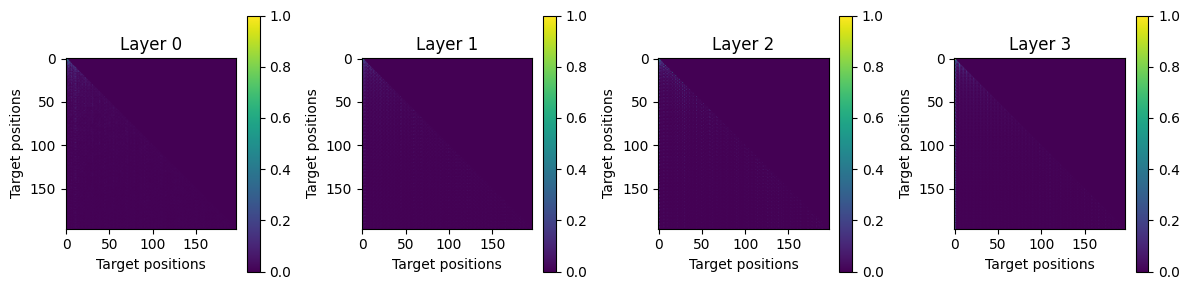

In [42]:
### Transformer attention visualization
opt_now = copy.deepcopy(opt)
opt_now.model_name = opt.model_name + "_with_attn"
model_now = transformer_model(opt_now)
model_now.to(device)

model_now.load_state_dict(torch.load(f"{model_dir}/model.pth"))
model_now.eval()

attn_weights = {}

def get_hook(name):
    def hook(module, input, output):
        attn_weights[name] = output[1].detach().cpu() 
    return hook

for i, layer in enumerate(model_now.decoder.layers):
    layer.self_attn.register_forward_hook(get_hook(f'layer_{i}_self_attn'))

con = torch.from_numpy(x_true[:1]).unsqueeze(-1).to(device)
seq = torch.from_numpy(y_true[0:1,:-1,:]).to(device)

if opt.use_flat_representation:
    seq = seq.reshape(len(seq), -1).unsqueeze(-1)

with torch.no_grad():
    _ = model_now(con, seq)

plt.figure(figsize=(3* opt_now.num_layers, 3))
for i in range(opt_now.num_layers):
    attn_matrix = attn_weights[f'layer_{i}_self_attn'][0].numpy()  # (tgt_len, tgt_len)

    plt.subplot(1, opt_now.num_layers, i + 1)
    plt.imshow(attn_matrix, cmap='viridis')
    plt.colorbar()
    plt.title(f"Layer {i}")
    plt.xlabel("Target positions")
    plt.ylabel("Target positions")

    plt.tight_layout()
    my_savefig(f"{output_dir}/attn_layer_{i}.pdf")


In [ ]:
# Count numbers for training/test

import h5py
file_path = "../dataset/TNG300-1/TNG300-1_33.h5"
with h5py.File(file_path, "r") as f:
    boxsize = f.attrs["BoxSize"]
    x = f["GroupMass"][:]
    y = f["SubhaloSFR"][:]
    pos = f["GroupPos"][:]
    num_subgroups = f["GroupNsubs"][:]

mask_halo = ( x > 1e11 ) 
mask_halo_test = mask_halo & ( pos > 0.5 * boxsize ).all(axis=1)

print("Total number of halos: {:d}".format(mask_halo.sum()))
print("Total number of halos for test: {:d}".format(mask_halo_test.sum()))

offset = 0
num_gal = 0
num_gal_test = 0
for j in range(len(x)):

    start = offset
    end = start + num_subgroups[j]
    offset = end
    if mask_halo[j]:
        y_now = y[start:end]
        mask_gal = ( y_now > 1e-3 )

        num_gal += mask_gal.sum()

        if mask_halo_test[j]:
            num_gal_test += mask_gal.sum()

print("Total number of galaxies: {:d}".format(num_gal))
print("Total number of galaxies for test: {:d}".format(num_gal_test))

print(mask_halo.sum() - mask_halo_test.sum())
print(num_gal - num_gal_test)

Total number of halos: 330287
Total number of halos for test: 38746
2329308
Total number of galaxies: 845631
Total number of galaxies for test: 99007
291541
746624
